In [2]:
from pyTNG import utils
from pyTNG import data_interface as _data_interface
import os
import pandas as pd
import numpy as np
import illustris_python as il
from pyTNG.spectra import StarSpectrumFactory
from pyTNG import spectra
import matplotlib.pyplot as plt
import time
import astropy.units as u
import scipy.integrate as integ
import pyTNG.utils as utils
from pyTNG.cosmology import TNGcosmo

In [5]:
%load_ext autoreload
%autoreload 2

In [3]:
h = TNGcosmo.h
snap_num = 13

In [4]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [5]:
basepath = "/virgo/simulations/IllustrisTNG/"
sim_name = 'L35n2160TNG'
sim = _data_interface.TNG50Simulation(os.path.join(basepath, sim_name))

In [126]:
dataset = next(sim.group_cat[snap_num].chunk_generator('subhalo'))

In [128]:
keys_needed = ['SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloHalfmassRadType', 'SubhaloMassInHalfRad', 
               'SubhaloMassInHalfRadType', 'SubhaloMassInRad', 'SubhaloMassInRadType', 'SubhaloSFRinHalfRad', 
               'SubhaloSFRinRad', 'SubhaloPos']

In [129]:
sub_dict = {key: test[key] for key in keys_needed}

In [130]:
dataset_df = utils.dfFromArrDict(sub_dict)

In [140]:
columns_of_interest = [('SubhaloGasMetallicity', 0), 
                       ('SubhaloGasMetallicityHalfRad',0),
                       ('SubhaloHalfmassRadType', 4),
                       ('SubhaloMassInHalfRad', 0),
                       ('SubhaloMassInHalfRadType', 4),
                       ('SubhaloMassInRad', 0),
                       ('SubhaloMassInRadType', 0),
                       ('SubhaloMassInRadType', 4),
                       ('SubhaloSFRinHalfRad', 0),
                       ('SubhaloSFRinRad', 0),
                       ('SubhaloPos', 0),
                       ('SubhaloPos', 1),
                       ('SubhaloPos', 2)
                      ]

Remove all halos that do not have any star particles or star formation rate

In [ ]:
def reduce_df(df):
    filt = (df[('SubhaloMassInRadType', 4)]>0) & (df[('SubhaloSFRinRad', 0)]>0)
    new_df = df[filt]
    return new_df

In [141]:
df_to_save = test_df[columns_of_interest]
df_to_save = reduce_df(df_to_save)

In [6]:
path = f'/ptmp/mpa/ivkos/semianalytic_fesc/testing/sn0{snap_num}.pickle'

In [12]:
df_to_save.to_pickle(path)

NameError: name 'df_to_save' is not defined

In [7]:
df = pd.read_pickle(path)

In [8]:
z_start = sim.snap_cat[snap_num].header['Redshift']

In [9]:
sim_path = os.path.join(basepath, sim_name, 'output')

In [ ]:
bpp = [
    '/ptmp/mpa/mglatzle/TNG_f_esc/BPASSv2.2.1_release-07-18-Tuatara/',
    '2.2.1',
    'chab300',
    'bin']
lam_min = None #approx 200ev
lam_max = None
specFac = StarSpectrumFactory(bpp)#,  lam_max=1000, lam_min=10,)

In [187]:
def get_stellar_dist(stars, df, index):
    gal_center = np.array([df.loc[index][('SubhaloPos',0)],df.loc[index][('SubhaloPos',1)],df.loc[index][('SubhaloPos',2)]])
    rel_pos = stars['Coordinates']-gal_center
    radius = df.loc[index][('SubhaloHalfmassRadType',4)]*2
    dist = np.sqrt(np.sum(np.square(rel_pos), axis=1))
    rel_dist = dist/radius
    stars['rel_dist'] = rel_dist
    return

In [188]:
stars = il.snapshot.loadSubhalo(sim_path,snap_num, 3,'stars')
utils.dropWindParticles(stars)
stars['Redshift'] = z_start
stars['ages'] = spectra._computeAgeFromFormationTime(stars['Redshift'],stars['GFM_StellarFormationTime'])
get_stellar_dist(stars, df, 3)
idces = stars['rel_dist']<1
utils._keepPartsByIdx(stars, idces)

In [189]:
specFac.computeStellarEmissivities(stars)

/freya/u/ivkos/pybpass/pyBPASS/database.py:137: UserWarning: Input metallicities for interpolation outside of available range 1e-05, 0.04 provided. They will be clipped.
  _warnings.warn(
/freya/u/ivkos/pybpass/pyBPASS/database.py:149: UserWarning: Input ages for interpolation outside of available range 1000000.0, 100000000000.0 [yr] provided. They will be clipped.
  _warnings.warn(


In [190]:
specFac.computeStellarSpectra(stars, Q_0=True)

In [44]:
luminosities = []
for i in range(stars['count']):
    integral = integ.simps(stars['spectra'][i], stars['lambda'])
    luminosities.append(integral)

In [93]:
new_df = pd.DataFrame()

Units: <br>
all masses: 10^10M_sun/h <br>
SFR: M_sun/h <br>
Radius: ckpc/h <br>
Luminosity: L_sun <br>

In [104]:
new_df['HaloMass'] = df[('SubhaloMassInRad',0)]
new_df['GasMass'] = df[('SubhaloMassInRadType',0)]
new_df['StarMass'] = df[('SubhaloMassInRadType',4)]
new_df['SFR'] = df[('SubhaloSFRinRad',0)]
new_df['Radius'] = 2*df[('SubhaloHalfmassRadType',4)]
new_df['Z'] = df[('SubhaloGasMetallicity',0)]

In [181]:
get_stellar_dist(stars, df, 3)

In [182]:
idces = stars['rel_dist']<1
utils._keepPartsByIdx(stars, idces)

In [185]:
stars['count']

618

In [172]:
idces

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [145]:
stars['Coordinates']

array([[24364.76548803, 18031.94515479, 14490.07894127],
       [24364.42979984, 18031.13904494, 14490.40675889],
       [24364.77926417, 18032.38568795, 14490.88037988],
       ...,
       [24389.15435489, 17978.07160794, 14482.52048033],
       [24394.11728012, 18008.01627702, 14465.22181288],
       [24337.049168  , 18051.51461562, 14583.7672712 ]])

In [154]:
for index in df.index:
    print(np.max(stars['Coordinates']-np.array([df.loc[index][('SubhaloPos',0)],df.loc[index][('SubhaloPos',1)],df.loc[index][('SubhaloPos',2)]])))
    print(np.min(stars['Coordinates']-np.array([df.loc[index][('SubhaloPos',0)],df.loc[index][('SubhaloPos',1)],df.loc[index][('SubhaloPos',2)]])))

307.98868509834574
-504.50358097060234
348.93508138514153
-138.54031838984884
179.77384134834574
-257.3014373561891
99.16164388514153
-138.28287784560234
202.85207357264153
-104.17117776484884
284.43985697334574
-467.18033878310234
245.31095072334574
-361.13932315810234
164.20743509834574
-505.68424503310234
183.00637044764153
-154.28971860618913
178.54727884834574
-390.79557315810234
135.34024759834574
-308.00455753310234
15.044608489908569
-605.6236981581023
112.20558919764153
-125.23893253310234
488.74649759834574
-692.8131512831023
448.71720072334574
-552.6149090956023
429.10782572334574
-511.97037784560234
126.54055013514153
-203.96940610618913
521.8246225983457
-690.1647137831023
478.70743509834574
-522.1647137831023
402.01407572334574
-529.6207684706023
230.22110697334574
-315.6764373561891
182.71915384834574
-251.01042173118913
125.49845072334574
-467.85123722060234
140.55509134834574
-251.19694034560234
516.3617319733457
-627.8639325331023
115.57266947334574
-488.6295575331023

6599.911795989909
-7328.825474639849
6496.346366302409
-7143.405552764849
20652.830970254596
293.4251251438109
20393.35758158272
474.6223907688109
20507.171790567096
271.7610626438109
20373.956458535846
149.04035951881087
20463.716712442096
341.3587188938109
20355.291419473346
517.8430938938109
20700.77017923897
132.80989076881087
20431.931067910846
387.3919220188109
20678.166907754596
153.23371889381087
20425.296790567096
337.9387970188109
20491.201575723346
252.68293764381087
20511.650794473346
304.8704376438109
20378.00894877022
559.3548126438109
20431.196692910846
219.31184389381087
20684.213782754596
197.99153139381087
20376.779212442096
156.11848451881087
20676.50455423897
339.1946563938109
20473.024329629596
297.8430938938109
20353.81851908272
503.4505157688109
20323.672278848346
534.2356720188109
20361.167396035846
510.1712188938109
20442.111243692096
371.0970001438109
21368.76773783272
-20433.924479408102
21436.27115580147
-20552.162760658102
21365.21939798897
-20548.694010658

13856.200599160846
-4989.615885658102
14035.946692910846
-4897.768229408102
13789.575599160846
-5106.172526283102
13706.008216348346
-5009.567057533102
14109.900794473346
-4848.598307533102
14229.678138223346
-4858.004557533102
13745.138099160846
-4995.926432533102
13874.273841348346
-4812.402995033102
13801.180091348346
-5011.942057533102
14187.926185098346
-4883.873698158102
14150.758216348346
-4852.996745033102
14143.722083535846
-4892.674479408102
13669.010169473346
-5002.610026283102
13848.929114785846
-5014.893229408102
13851.173255410846
-5007.526041908102
13806.789466348346
-5024.928385658102
13956.762122598346
-4939.692057533102
13855.547278848346
-5169.395182533102
13750.918372598346
-5134.705729408102
13825.879310098346
-5002.317057533102
13966.083411660846
-4907.367838783102
13691.206458535846
-5003.434245033102
13975.201575723346
-4894.580729408102
13920.177161660846
-4991.813151283102
14104.341224160846
-4861.348307533102
13870.003333535846
-4971.266276283102
13928.983802

18920.449134317096
2239.1018877793977
18945.009192910846
2181.075515768811
19053.395911660846
2210.4290362168977
19160.913001504596
2246.9270830918977
19146.951575723346
2189.8479815293977
19017.457435098346
2186.2903643418977
19102.128821817096
2175.9778643418977
19161.796790567096
2217.6761065293977
19140.744056192096
2246.4095049668977
18961.722571817096
2204.2112627793977
14606.381278411784
1852.0221816101512
14644.416678802409
1927.1178847351512
14785.080253021159
2067.184290985151
14897.640067474284
2066.873744110151
14670.438895599284
1962.0065566101512
14626.830985443034
1901.1081191101512
14733.586112396159
2107.442103485151
14825.546073333659
2048.487025360151
14688.830253021159
1983.8952284851512
14601.151786224284
1924.8854628601512
14580.965262786784
1880.0690566101512
14729.110770599284
2090.506556610151
14876.040946380534
2066.832728485151
14891.114676849284
2096.492884735151
14493.042655364909
2359.184290985151
14646.164969818034
2374.266322235151
14475.396903411784
247

11453.819510833659
-16184.170573158102
11492.233573333659
-16255.834635658102
11483.465506927409
-16359.328776283102
11480.311210052409
-16187.848307533102
11547.015311614909
-16437.002604408102
11466.683768646159
-16309.131510658102
11437.993338958659
-16207.824870033102
11498.677909271159
-16310.131510658102
11463.802420989909
-16304.194010658102
11526.491385833659
-16380.934245033102
11619.713553802409
-16520.610026283102
11507.590018646159
-16327.438151283102
11467.935233489909
-16324.543620033102
11123.543968103892
2099.780593893811
11436.642845057017
2099.832351706311
11328.651145838267
2051.731765768811
11286.182884119517
2187.428054831311
11150.831809900767
2136.544265768811
11308.259300135142
2074.076492331311
11271.338645838267
2233.551478485151
11314.776878260142
1992.5012970188109
11359.125022791392
2064.334304831311
11407.657249353892
2114.787429831311
11146.859641932017
2151.881556610151
11141.465598963267
2087.827468893811
11395.804466150767
2111.924148581311
11461.45436

...

-9931.572916908102
10027.613944427409
-9946.764323158102
16581.67021884147
-13530.594401283102
23706.457007852252
-1106.8492840956023
23683.792396035846
-1158.1236981581023
23705.419898477252
-1133.0299481581023
7025.191810098346
-1684.5904950331023
15438.991629974284
4563.195637779398
7721.1240462288915
-13231.93815610619
7730.0288313851415
-13181.68229673119
6844.237967864909
-4222.727213783102
6843.392264739909
-4209.110026283102
16548.042396035846
9092.203938560648
18214.487708535846
4814.022786216898
18200.745032754596
4851.725911216898
18195.804114785846
4853.188801841898
17920.030707733073
-16973.633463783102
18005.549262420573
-16953.467448158102
17946.767226592936
-16952.735026283102
17866.66730441276
-16975.360026283102
17964.601989166178
-16967.731120033102
17898.739936248698
-16973.547526283102
16953.661185638346
-6544.588541908102
16980.373954193034
-6552.527995033102
11454.194114588267
1206.0749159851512
11423.122337244517
1179.2253066101512
11440.393577478892
1215.778040

9909.276389978892
8030.539382956311
9933.455100916392
8014.546218893811
9953.970237635142
8005.770828268811
14394.577567474284
2889.424525360151
14385.553397552409
2900.293665985151
23472.91001078194
-15808.62956235619
23482.24692484444
-15823.31315610619
22198.29166361397
676.7259063938109
18654.240149942096
4954.690754966898
18689.586829629596
4967.481770591898
13742.300208535846
-8507.33073423119
14538.501808069712
-4142.698521514849
14462.086624048716
-4173.358677764849
14501.103935144907
-4162.753209014849
14528.345664881235
-4156.970005889849
9195.741874114909
-10124.578776283102
9213.398124114909
-10164.160807533102
11398.988944427409
-10441.813755889849
10147.814856973346
-18387.664713783102
10156.947669473346
-18363.014323158102
23654.238868203814
-19522.752604408102
23709.923621621783
-19567.635416908102
23628.458106485064
-19504.080729408102
16466.805579629596
-3639.9303387831023
16471.295814004596
-3608.3658856581023
9567.368675135142
-9594.26628110619
15628.843680755534
86

-15254.221354408102
12639.040672205454
63.001297018810874
12592.694114588267
40.565750143810874
12567.334251307017
33.069656393810874
19246.692786660846
-299.6979217311891
19263.216712442096
-272.8678436061891
6458.748450723346
-8758.680338783102
12205.929374114909
2883.139369110151
12200.406424896159
2879.768275360151
4617.906653848346
-4481.719401283102
4577.058997598346
-4479.654948158102
4617.719153848346
-4483.942057533102
5465.729178802409
758.4866534043977
11518.104270838267
1029.6673126438109
11483.436546228892
991.9368438938109
11486.548850916392
1039.6262970188109
14113.98833455897
10806.577845672651
14092.313102625376
10809.905970672651
9297.716483489909
-13742.410807533102
9297.893241302409
-13735.563151283102
12265.862479583659
-18076.067057533102
12251.661307708659
-18097.174479408102
12254.475760833659
-18050.647135658102
9820.642112635142
1425.0071563938109
9795.416526697642
1448.2415313938109
9840.950706385142
1439.8372345188109
9830.915061853892
1435.2102813938109
981

448.2063751438109
17920.621375457682
-1555.1164902648488
17903.25891818229
-1537.4348496398488
10807.478782557017
-6602.922531106189
10833.519554041392
-6614.994796731189
11212.047049896159
-1787.3000840148488
11219.358573333659
-1822.1125840148488
11226.542167083659
-1806.0188340148488
14485.079505823618
-5926.641880889849
9031.412772552409
-6097.655552764849
9023.473319427409
-6114.198521514849
12861.848060098346
367.1634063938109
12853.586341348346
403.5345001438109
12882.560950723346
347.2298126438109
4797.4468001351415
-10002.446568389849
4802.6762923226415
-10003.438755889849
13213.560721771159
-13667.817057533102
13222.294120208659
-13691.350260658102
13225.406913177409
-13706.160807533102
13190.777030364909
-13636.736979408102
13238.275565521159
-13687.684245033102
10080.414237396159
4065.684290985151
10057.100760833659
4030.178431610151
7802.7207259163915
-15627.93815610619
7796.7656477913915
-15638.55534360619
7796.8789290413915
-15657.57878110619
20712.859778848346
1931.7093

KeyboardInterrupt: 

In [115]:
summed_spectrum = stars['spectra'].sum(axis=0)

lambda_expect = integ.simps(summed_spectrum*stars['lambda'], stars['lambda'])/integ.simps(summed_spectrum, stars['lambda'])

In [117]:
lambda_expect

3266.37739726843

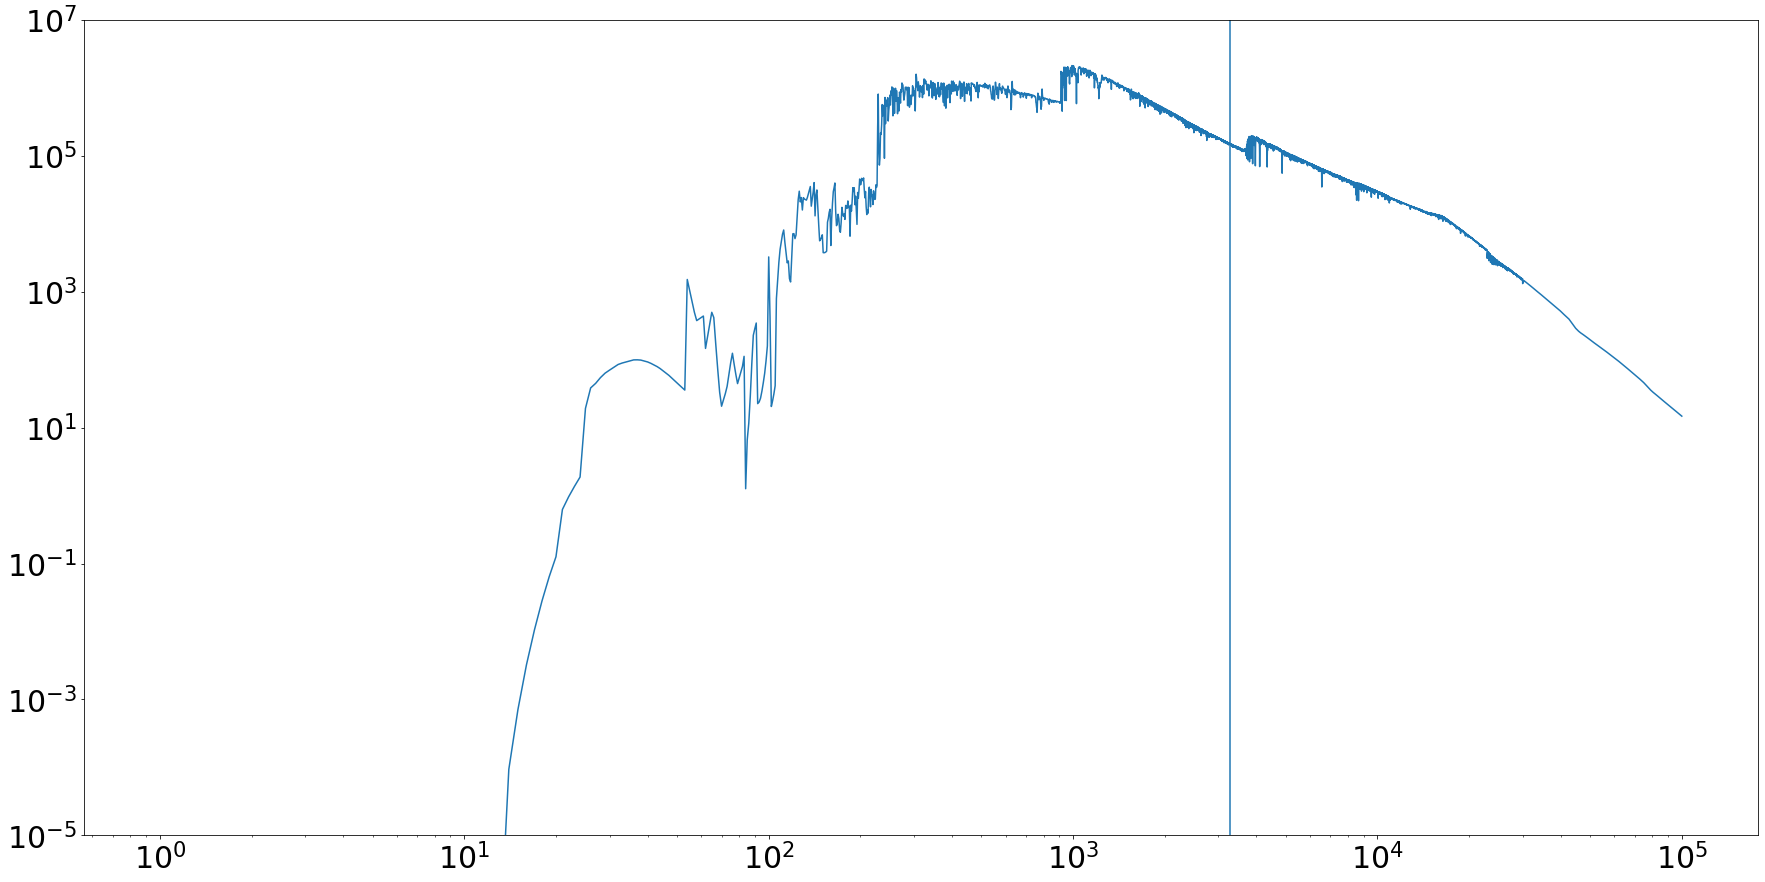

In [123]:
# for i in range(100):
#     plt.plot(stars['lambda'], stars['spectra'][8*i])
plt.plot(stars['lambda'],summed_spectrum)
plt.vlines(3266, 1e-5, 1e7)
plt.yscale('log')
plt.ylim(1e-5,1e7)
plt.rc('xtick', labelsize=30) 
plt.rc('ytick', labelsize=30)
plt.xscale('log')
plt.rcParams["figure.figsize"] = (30,15)